# AI Resume Screener — Pipeline Smoke Test (Real Data)

This notebook exercises the full LangGraph pipeline with **real documents** from the `data/raw` directory to verify:
1. `document_parser` correctly extracts text from PDF/DOCX.
2. All four nodes execute without import or schema errors.
3. LLM returns valid structured output for complex real-world inputs.
4. Post-processing (experience calculation, soft skill normalisation) runs correctly on real data.

In [1]:
import os
import sys
import json
from IPython.display import JSON, display

# Add project root to sys.path
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..")))

from src.agents.graph import screener_app
from src.utils.document_parser import parse_document

In [2]:
# Define paths to real documents
JD_PATH = "../data/raw/jds/backend_software_engineer_openai.pdf"
RESUME_PATH = "../data/raw/resumes/maya_thompson_res_backend_software_engineer_c08.pdf"

print(f"Loading JD from: {JD_PATH}")
REAL_JD = parse_document(JD_PATH)

print(f"Loading Resume from: {RESUME_PATH}")
REAL_RESUME = parse_document(RESUME_PATH)

print(f"\nJD Length: {len(REAL_JD)} chars")
print(f"Resume Length: {len(REAL_RESUME)} chars")

Loading JD from: ../data/raw/jds/backend_software_engineer_openai.pdf
Loading Resume from: ../data/raw/resumes/maya_thompson_res_backend_software_engineer_c08.pdf

JD Length: 4726 chars
Resume Length: 3096 chars


In [3]:
initial_state = {
    "jd_text": REAL_JD,
    "resume_text": REAL_RESUME,
}

print("Running full LangGraph pipeline on real data...")
final_state = await screener_app.ainvoke(initial_state)
print("✅ Successfully executed the pipeline")

Running full LangGraph pipeline on real data...
✅ Successfully executed the pipeline


In [5]:
import json

print("📋 JD EXTRACTION")
print(json.dumps(final_state["jd_skills"].model_dump(), indent=2))

print("\n👤 RESUME EXTRACTION")
print(json.dumps(final_state["resume_skills"].model_dump(), indent=2))

print("\n🔍 GAP ANALYSIS")
print(json.dumps(final_state["gap_analysis"].model_dump(), indent=2))

print("\n✅ FINAL RECOMMENDATION")
print(json.dumps(final_state["final_recommendation"].model_dump(), indent=2))

📋 JD EXTRACTION
{
  "job_title": "Backend Software Engineer, ChatGPT Engineering",
  "company_name": "OpenAI",
  "required_technical_skills": [
    "distributed systems",
    "APIs",
    "Go",
    "Python",
    "Rust",
    "C++",
    "system design"
  ],
  "nice_to_have_skills": [],
  "required_years_of_experience": null,
  "minimum_education_level": null,
  "core_responsibilities": [
    "Architect, build, and improve scalable backend systems and APIs.",
    "Drive performance, reliability, and security across distributed services.",
    "Implement data storage, retrieval, compute, and integration solutions.",
    "Participate in long-term architectural planning and technical design reviews.",
    "Work closely with product, data science, and frontend teams."
  ],
  "domain_experience": [],
  "soft_skills": [
    "collaboration",
    "operational excellence"
  ]
}

👤 RESUME EXTRACTION
{
  "candidate_name": "Maya Thompson",
  "contact_email": "maya.thompson.eng@gmail.com",
  "contact_p

✅ Graph saved to ../assets/pipeline_graph.png


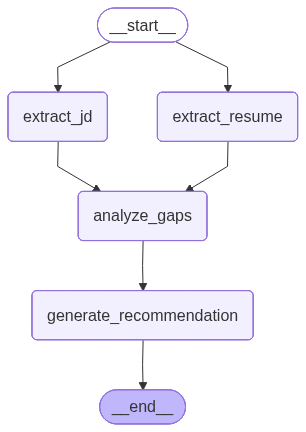

In [6]:
import os
from IPython.display import Image, display
from src.agents.graph import screener_app

output_path = "../assets/pipeline_graph.png"

# Generate and save
img_bytes = screener_app.get_graph().draw_mermaid_png()

with open(output_path, "wb") as f:
    f.write(img_bytes)

print(f"✅ Graph saved to {output_path}")
display(Image(img_bytes))